# IPL Data Pipeline - Exploration Notebook

This notebook demonstrates:
- Loading IPL match data
- Cleaning and processing
- Analyzing statistics
- Visualizing results


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raw/ipl_matches.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()


,date,team1,team2,winner,runs_team1,runs_team2
0,2024-04-01,CSK,KKR,CSK,180,175
1,2024-04-02,MI,RCB,RCB,200,198
2,2024-04-03,RCB,DC,DC,150,155
3,2024-04-04,SRH,MI,SRH,190,170
4,2024-04-05,DC,CSK,CSK,160,158


## 1. Summary Statistics
Overview of matches, teams, and runs.


In [2]:
print("Total Matches:", len(df))
print("Teams:", sorted(set(df["team1"]).union(df["team2"])))
print("Average Runs Team1:", df["runs_team1"].mean())
print("Average Runs Team2:", df["runs_team2"].mean())
print("Most Frequent Winners:", df["winner"].value_counts().to_dict())


Total Matches: 39
Teams: ['CSK', 'DC', 'KKR', 'MI', 'RCB', 'SRH']
Average Runs Team1: 189.94871794871796
Average Runs Team2: 183.12820512820514
Most Frequent Winners: {'RCB': 8, 'SRH': 8, 'CSK': 6, 'DC': 6, 'KKR': 6, 'MI': 5}


## 2. Runs Comparison
Compare runs scored by Team1 vs Team2.


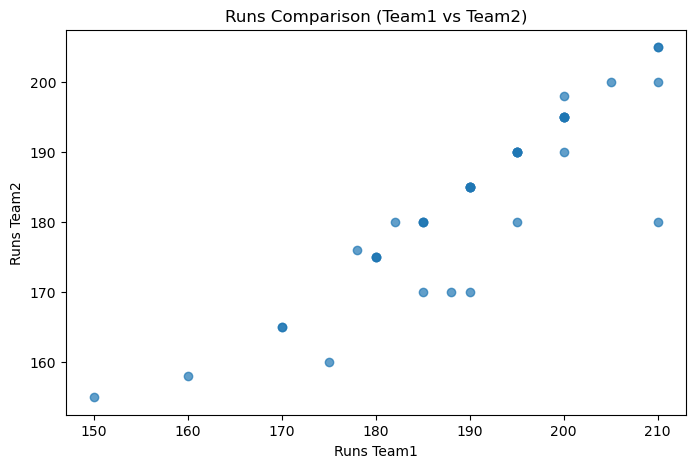

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(df["runs_team1"], df["runs_team2"], alpha=0.7)
plt.xlabel("Runs Team1")
plt.ylabel("Runs Team2")
plt.title("Runs Comparison (Team1 vs Team2)")
plt.show()


## 3. Winners Distribution
Count how many matches each team won.


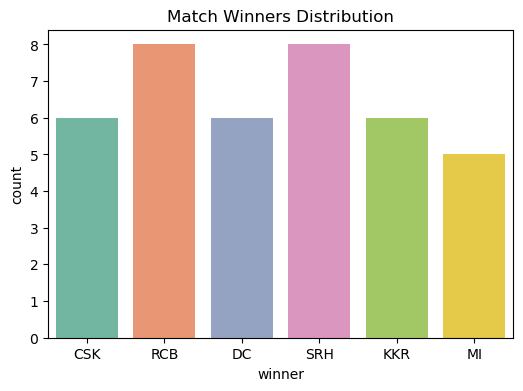

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="winner", data=df, palette="Set2")
plt.title("Match Winners Distribution")
plt.show()


## 4. Runs Trend Over Time
Visualize runs scored across match dates.


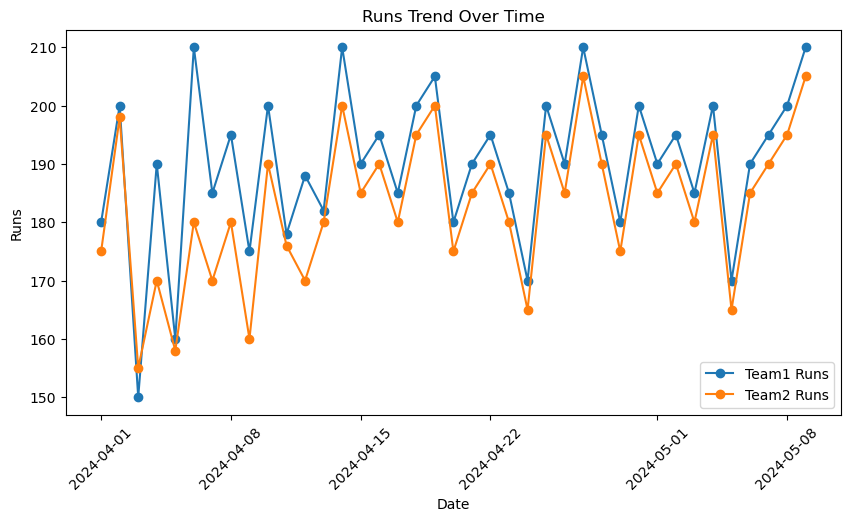

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df["date"], df["runs_team1"], marker="o", label="Team1 Runs")
plt.plot(df["date"], df["runs_team2"], marker="o", label="Team2 Runs")
plt.xticks(rotation=45)
plt.title("Runs Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Runs")
plt.legend()
plt.show()


## 5. Correlation Heatmap
Check correlations between numeric features.


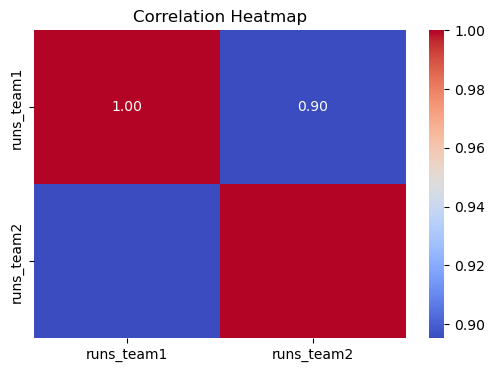

In [6]:
df_numeric = df.select_dtypes(include=["number"])
plt.figure(figsize=(6,4))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 6. Top Teams by Wins
Rank teams by number of wins.


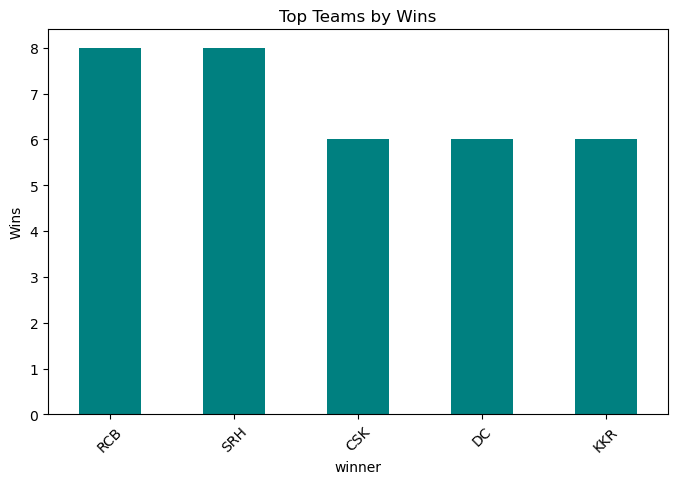

In [7]:
top_winners = df["winner"].value_counts().head(5)

plt.figure(figsize=(8,5))
top_winners.plot(kind="bar", color="teal")
plt.title("Top Teams by Wins")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()
